# EMPLOYEE LAYOFFS DATA ANALYST

## IMPORT LIBRARY AND DATA

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('layoffs.csv')
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year


## DATA CLEANING

In [20]:

df = df.drop_duplicates()

df = df.dropna(
    subset=['total_laid_off', 'percentage_laid_off'],
    how='all'
)
df['total_laid_off'] = df['total_laid_off'].fillna(0)
df['percentage_laid_off'] = df['percentage_laid_off'].fillna(0)
df['funds_raised'] = df['funds_raised'].fillna(0)
df['location'] = df['location'].fillna('Unknown') 



##                                                                                  EDA

### TOTAL  5 EMPLOYEE LAYOFFS BY LOCATTION

Text(0, 0.5, 'Location')

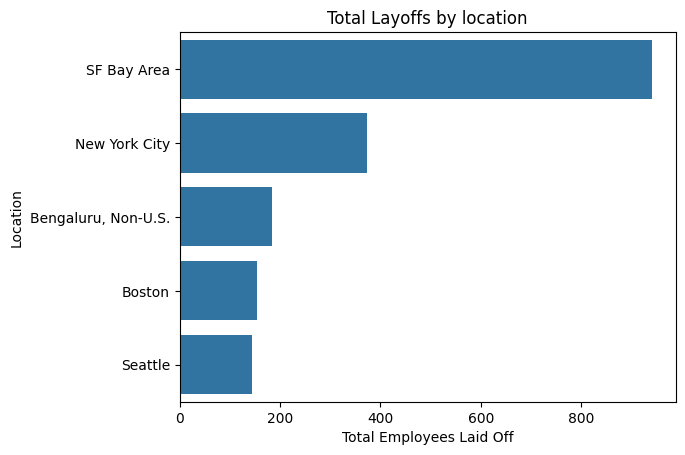

In [ ]:

location_counts = df.groupby('location').size().reset_index(name='count').sort_values(by='count', ascending=False)
ax = sns.barplot(data=location_counts.head(5), x='count', y='location')

ax.set_title('Total Layoffs by location')
ax.set_xlabel('Total Employees Laid Off')
ax.set_ylabel('Location')

### TOP 5 INDUSTRY WITH THE MOST LAYOFFS EMPLOYEE

Text(0, 0.5, 'Total Employees Laid Off')

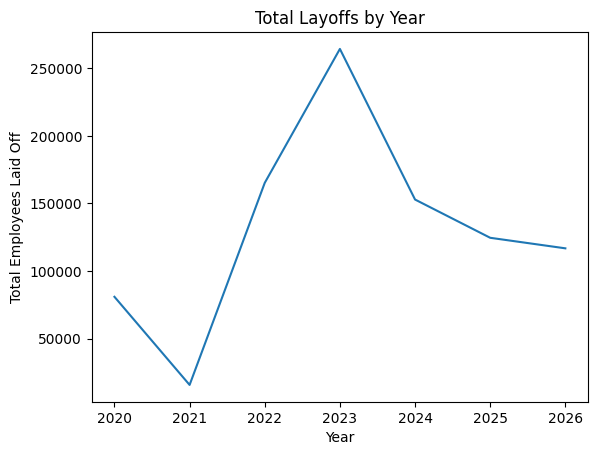

In [ ]:
year_layoffs = df.groupby('year')['total_laid_off'].sum().reset_index()

ax = sns.lineplot(data=year_layoffs, x='year', y='total_laid_off')
ax.set_title('Total Layoffs by Year')
ax.set_xlabel('Year')
ax.set_ylabel('Total Employees Laid Off')


### LAYOFFS TREN IN 2026 

Text(0, 0.5, 'Total Employees Laid Off')

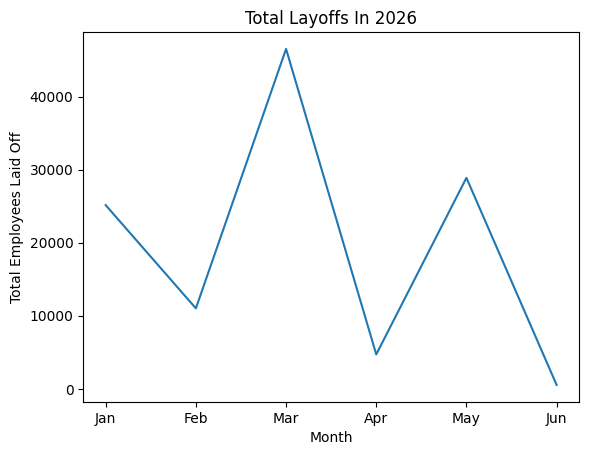

In [ ]:
df_2026 = df[df['date'].dt.year == 2026]
layoff_per_month = (
    df_2026
    .groupby(df_2026['date'].dt.strftime('%b'))['total_laid_off']
    .sum()
    .reindex([
        'Jan','Feb','Mar','Apr','May','Jun'
    ])
)

layoff_per_month = layoff_per_month.reset_index()
layoff_per_month.columns = ['month', 'count']

ax = sns.lineplot(data=layoff_per_month, x='month', y='count')
ax.set_title('Total Layoffs In 2026')
ax.set_xlabel('Month')
ax.set_ylabel('Total Employees Laid Off')

### TOP 5  TOTAL LAYOFFS BY COUNTRY

Text(0, 0.5, 'Country')

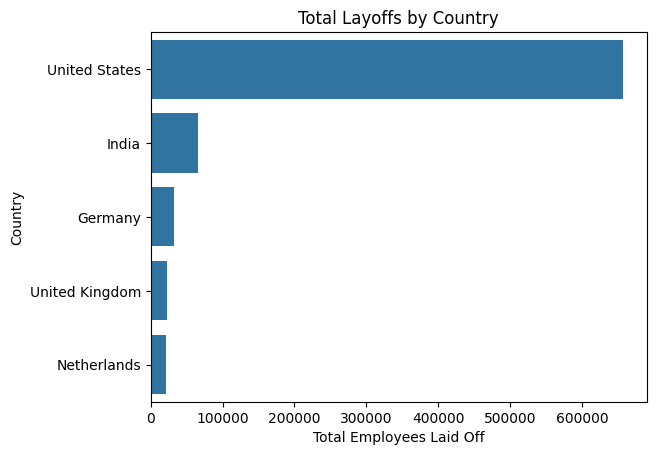

In [ ]:
country_count = df.groupby('country')['total_laid_off'].sum().reset_index(name='count').sort_values(by='count', ascending=False)

ax = sns.barplot(data=country_count.head(5), x='count', y='country')
ax.set_title('Total Layoffs by Country')
ax.set_xlabel('Total Employees Laid Off')
ax.set_ylabel('Country')

### TOP 5 INDUSTRY WITH THE MST HIGHEST LAYOFS EMPLOYEE


Text(0, 0.5, 'Industry')

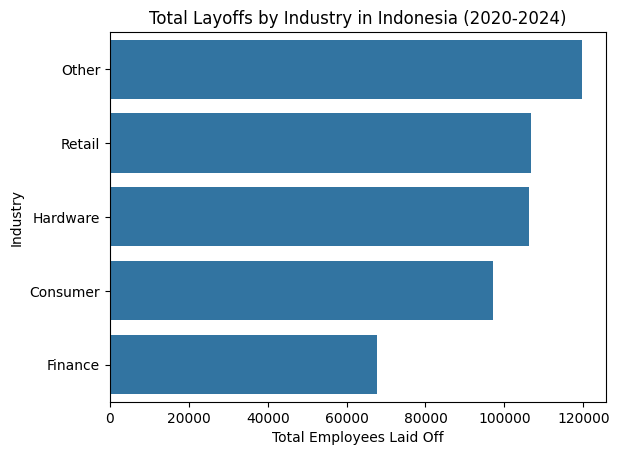

In [ ]:

industry = df.groupby('industry')['total_laid_off'].sum().reset_index(name='count').sort_values(by='count', ascending=False)

ax = sns.barplot(data=industry.head(5), x='count', y='industry')
ax.set_title('Total Layoffs by Industry in Indonesia (2020-2024)')
ax.set_xlabel('Total Employees Laid Off')
ax.set_ylabel('Industry')

### TOP 5 INDUSTRY WITH THE HIGHEST LAYOFFS IN INDONESIA IN 2020 - 2024

Text(0, 0.5, 'Industry')

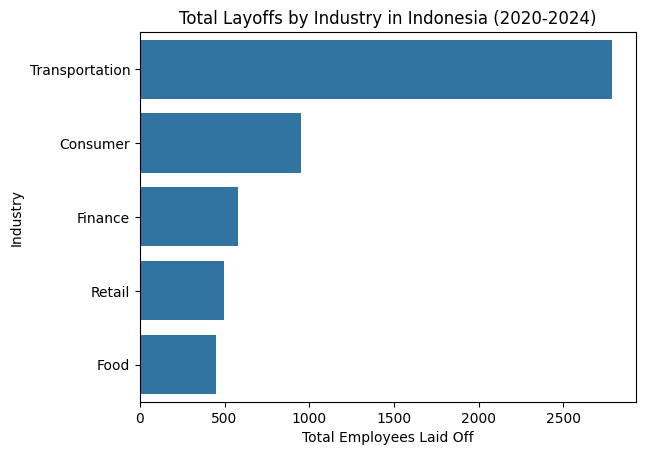

In [ ]:


df_indo = df[df['country'] == 'Indonesia']

industry = df_indo.groupby('industry')['total_laid_off'].sum().reset_index(name='count').sort_values(by='count', ascending=False)

ax = sns.barplot(data=industry.head(5), x='count', y='industry')
ax.set_title('Total Layoffs by Industry in Indonesia (2020-2024)')
ax.set_xlabel('Total Employees Laid Off')
ax.set_ylabel('Industry')

### TOP 5 COMPANY WITH THE HIGEST LAYOFFS 

Text(0, 0.5, 'Industry')

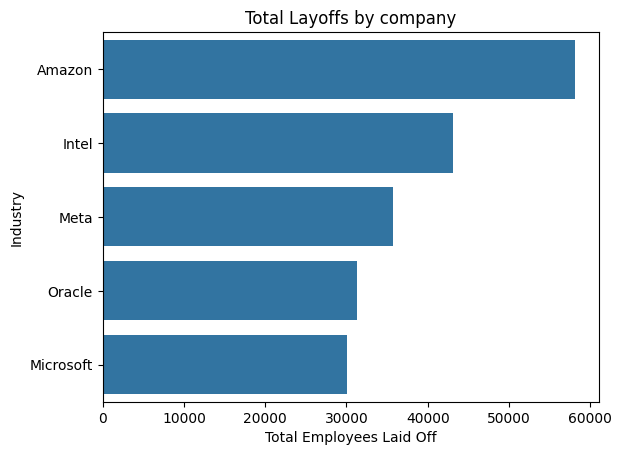

In [ ]:
company_count = df.groupby('company')['total_laid_off'].sum().reset_index(name='count').sort_values(by='count', ascending=False)

ax = sns.barplot(data=company_count.head(5), x='count', y='company')
ax.set_title('Total Layoffs by company')
ax.set_xlabel('Total Employees Laid Off')
ax.set_ylabel('Industry')

### TOTAL LAIDOFFS BY FUNDINGS STAGE

C:\Users\Hype\AppData\Local\Temp\ipykernel_9372\1018548067.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


Text(0, 0.5, 'Funding Stage')

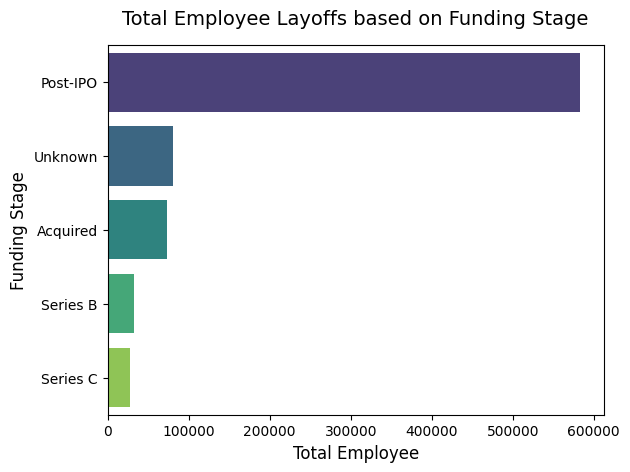

In [13]:
stage_analysis = df.groupby('stage').agg(
    total_phk=('total_laid_off', 'sum'),
    rata_rata_phk=('total_laid_off', 'mean'),
    jumlah_kejadian=('total_laid_off', 'count')
).sort_values(by='total_phk', ascending=False).reset_index()

# Tampilkan hasil tabel agregasi

ax = sns.barplot(
    x='total_phk', 
    y='stage', 
    data=stage_analysis.head(5), 
    palette='viridis'
)



ax.set_title('Total Employee Layoffs based on Funding Stage' , fontsize=14, pad=15)
ax.set_xlabel('Total Employee', fontsize=12)
ax.set_ylabel('Funding Stage', fontsize=12)

# ax.tight_layout()
# ax.show()

### TOTAL LAIDOF SIZE CLASSIFICATION

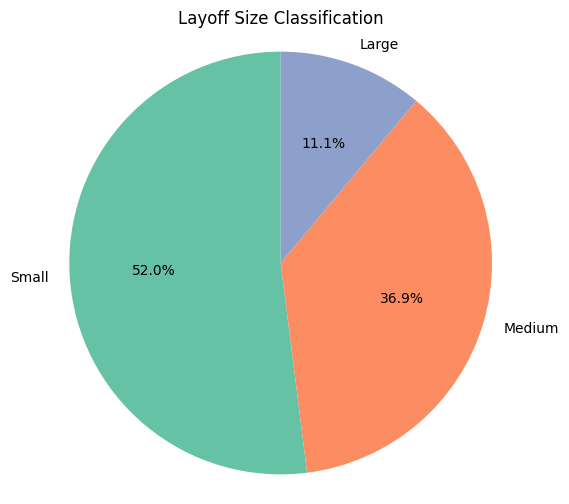

In [ ]:


def classify_layoff(total_laid_off):
    if pd.isna(total_laid_off):
        return np.nan
    if total_laid_off < 100:
        return 'Small'
    elif total_laid_off < 500:
        return 'Medium'
    else:
        return 'Large'

df['layoff_size'] = df['total_laid_off'].apply(classify_layoff)

layoff_size_counts = df['layoff_size'].value_counts().reindex(['Small', 'Medium', 'Large'])

colors = sns.color_palette('Set2', n_colors=len(layoff_size_counts))

plt.figure(figsize=(6, 6))
plt.pie(
    layoff_size_counts,
    labels=layoff_size_counts.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90
)
plt.title('Layoff Size Classification')
plt.axis('equal')
plt.show()

## SUMARY
## ----------------------------------------------------------------------------------------------------

##### - Employee layoffs increased significantly between 2021 and 2023, indicating a period of workforce reduction across many companies. This trend may be associated with post-pandemic business adjustments and broader economic uncertainty.
 
##### - The "Others" category had the highest number of layoffs. Further analysis showed that the majority of companies in this category were from the technology sector, so the technology industry remains the primary contributor to layoffs in the dataset.

##### - Amazon recorded the highest number of laid-off employees among all companies in the dataset, indicating that even large and well-established technology companies were not immune to workforce reductions during this period.

 ##### - Companies in the IPO stage accounted for the largest number of laid-off employees. This suggests that business maturity and access to public funding do not necessarily protect companies from workforce reductions, as many firms continue to prioritize operational efficiency and profitability.

 ##### - Layoffs peaked in March 2026. While the dataset does not provide the reasons behind these layoffs, the increase may be associated with broader economic conditions, technological changes, or company restructuring efforts.